# Electricity price floor & asymmetry techniques comparison

In [1]:
import os
import sys
import json
import gc
import warnings
from pathlib import Path
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

current_dir = Path.cwd()
project_root = None
if (current_dir / 'config.py').exists():
    project_root = str(current_dir)
elif (current_dir.parent / 'config.py').exists():
    project_root = str(current_dir.parent)

if project_root and project_root not in sys.path:
    sys.path.insert(0, project_root)

from config import ExperimentConfig, DataConfig, ModelConfig, TrainingConfig
from data import DataPipeline
from models import (
    ProbabilisticTransformer,
    HybridProbabilisticTransformer,
    HybridProbabilisticTransformerReflectedOU,
    HybridProbabilisticTransformerCIR,
    HybridProbabilisticTransformerPostHocFloor,
)
from core.trainer import Trainer
from transformations import StandardScalingTransformation

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

try:
    gpus = tf.config.experimental.list_physical_devices("GPU")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPUs detected: {len(gpus)}")
except Exception as e:
    print(f"GPU config failed: {e}")

2026-03-03 18:10:06.550926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772557806.649099 2403261 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772557806.687900 2403261 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772557806.882215 2403261 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772557806.882251 2403261 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772557806.882256 2403261 computation_placer.cc:177] computation placer alr

GPUs detected: 1


In [2]:
# Configuration
RESULTS_DIR = Path(project_root) / "results" / "price_floor_comparison"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = RESULTS_DIR / "results.json"

N_RUNS = 5
INPUT_WINDOW = 168
OUTPUT_HORIZON = 24

BASE_MODEL_CONFIG = {
    "d_model": 128,
    "num_heads": 4,
    "num_layers": 2,
    "ff_dim": 256,
    "dropout": 0.1,
}

TRAIN_SETTINGS = {
    "batch_size": 64,
    "epochs": 30,
    "learning_rate": 1e-3,
    "patience": 5,
}

In [3]:
def calculate_metrics(y_true, y_pred):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mae = mean_absolute_error(y_true_flat, y_pred_flat)
    rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))
    r2 = r2_score(y_true_flat, y_pred_flat)
    mask = y_true_flat != 0
    mape = np.mean(np.abs((y_true_flat[mask] - y_pred_flat[mask]) / y_true_flat[mask])) * 100 if mask.any() else 0.0
    return {"MAE": float(mae), "RMSE": float(rmse), "MAPE": float(mape), "R2": float(r2)}

def pinball_loss(y_true, y_pred_q, q):
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred_q.flatten()
    err = y_true_flat - y_pred_flat
    return np.mean(np.maximum(q * err, (q - 1.0) * err))

def compute_interval_metrics(y_true, q_low, q_high, alpha=0.05):
    """PICP, MPIW, PINAW, Interval score for (1-alpha)*100% prediction interval."""
    y_flat = y_true.flatten()
    q_low_flat = q_low.flatten()
    q_high_flat = q_high.flatten()
    covered = (y_flat >= q_low_flat) & (y_flat <= q_high_flat)
    picp = float(np.mean(covered))
    mpiw = float(np.mean(q_high_flat - q_low_flat))
    y_range = np.max(y_flat) - np.min(y_flat)
    pinaw = float(mpiw / y_range) if y_range > 0 else 0.0
    width = q_high_flat - q_low_flat
    lower_penalty = (2 / alpha) * (q_low_flat - y_flat) * (y_flat < q_low_flat)
    upper_penalty = (2 / alpha) * (y_flat - q_high_flat) * (y_flat > q_high_flat)
    interval_score = float(np.mean(width + lower_penalty + upper_penalty))
    return {"PICP": picp, "MPIW": mpiw, "PINAW": pinaw, "IntervalScore": interval_score}

def compute_crps(y_true, samples):
    """CRPS via sampling: E|X-y| - 0.5*E|X-X'|."""
    y_flat = y_true.flatten()
    samples_flat = samples.reshape(samples.shape[0], -1)
    y_exp = np.expand_dims(y_flat, axis=0)
    term1 = np.mean(np.abs(samples_flat - y_exp), axis=0)
    samples_sorted = np.sort(samples_flat, axis=0)
    N = samples_sorted.shape[0]
    term2_sum = np.sum((2 * np.arange(N) - N + 1) * samples_sorted.T, axis=1)
    term2 = term2_sum / (N * N)
    crps_per = term1 - term2
    return float(np.mean(crps_per))

def load_cache() -> Dict[str, Any]:
    if CACHE_FILE.exists():
        try:
            with open(CACHE_FILE, "r") as f:
                return json.load(f)
        except json.JSONDecodeError:
            return {}
    return {}

def save_cache(cache: Dict[str, Any]) -> None:
    with open(CACHE_FILE, "w") as f:
        json.dump(cache, f, indent=2)

In [4]:
# Load and preprocess data
print("Loading Data...")
data_config = DataConfig(dataset_name="BE_ENTSOE", input_window=INPUT_WINDOW, output_horizon=OUTPUT_HORIZON)
pipeline = DataPipeline(data_config)
df_train, df_val, df_test = pipeline.get_data_splits()

df_train = df_train.ffill().bfill()
df_val = df_val.ffill().bfill()
df_test = df_test.ffill().bfill()

X_train, y_train = pipeline.create_sequences(df_train)
X_val, y_val = pipeline.create_sequences(df_val)
X_test_raw, y_test_raw = pipeline.create_sequences(df_test)

scaler = StandardScalingTransformation()
scaler.fit(X_train, y_train)
X_train_s, y_train_s = scaler.transform(X_train, y_train)
X_val_s, y_val_s = scaler.transform(X_val, y_val)
X_test_s, y_test_s = scaler.transform(X_test_raw, y_test_raw)

print(f"Train: {X_train_s.shape}, Test: {X_test_s.shape}")

Loading Data...
Train: (19509, 168, 28), Test: (13087, 168, 28)


In [5]:
# Model configurations: (display_name, model_class, head_type, head_params, is_hybrid, apply_posthoc_floor)
MODEL_CONFIGS = [
    ("Baseline (Gaussian)", ProbabilisticTransformer, "gaussian", {}, False, False),
    ("Baseline (Johnson SU)", ProbabilisticTransformer, "johnson_su", {}, False, False),
    ("Johnson SU + Floor", ProbabilisticTransformer, "johnson_su_floor", {"floor_penalty_weight": 0.1, "asymmetric_weight": 1.5}, False, False),
    ("Truncated Normal", ProbabilisticTransformer, "truncated_normal", {}, False, False),
    ("Transformer + PostHoc Floor", ProbabilisticTransformer, "johnson_su", {}, False, True),
    ("Hybrid (Transformer+OU)", HybridProbabilisticTransformer, "johnson_su", {}, True, False),
    ("Hybrid + Reflected OU", HybridProbabilisticTransformerReflectedOU, "johnson_su", {}, True, False),
    ("Hybrid + CIR", HybridProbabilisticTransformerCIR, "johnson_su", {}, True, False),
    ("Hybrid + PostHoc Floor", HybridProbabilisticTransformerPostHocFloor, "johnson_su", {}, True, False),
]

In [ ]:
cache = load_cache()

for model_name, model_cls, head_type, head_params, is_hybrid, apply_posthoc_floor in MODEL_CONFIGS:
    if model_name in cache:
        print(f"Results for {model_name} found in cache. Skipping.")
        continue

    print(f"\n{'='*60}")
    print(f"Running: {model_name}")
    print(f"{'='*60}")
    run_metrics = []

    for r in range(N_RUNS):
        print(f"  Run {r+1}/{N_RUNS}...")
        tf.keras.backend.clear_session()
        gc.collect()

        model_conf = ModelConfig(**BASE_MODEL_CONFIG)
        train_conf = TrainingConfig(**TRAIN_SETTINGS)
        dc = DataConfig("BE_ENTSOE", input_window=INPUT_WINDOW, output_horizon=OUTPUT_HORIZON)
        exp_conf = ExperimentConfig(
            name=f"{model_name}_run{r}",
            data_config=dc,
            model_config=model_conf,
            training_config=train_conf,
            head_type=head_type,
            head_params=head_params,
        )

        model = model_cls(exp_conf)
        trainer = Trainer(exp_conf)

        try:
            trainer.train(model, X_train_s, y_train_s, X_val_s, y_val_s)
        except Exception as e:
            print(f"    Training Error: {e}")
            continue

        q_list = [0.025, 0.1, 0.5, 0.9, 0.975]
        n_crps_samples = 200

        if is_hybrid:
            model.fit_ou(X_train_s, y_train_s)
            y_pred_scaled = model.predict_hybrid(X_test_s, last_residuals=None)
            q_scaled_dict = model.quantiles_hybrid(X_test_s, q_list, n_samples=n_crps_samples)
            samples_scaled = model.sample_hybrid(X_test_s, n_samples=n_crps_samples, last_residuals=None)
        else:
            y_params = model.keras_model.predict(X_test_s, verbose=0)
            flat_params = y_params.reshape(-1, y_params.shape[-1])
            y_pred_scaled_flat = model.head.mean(flat_params)
            y_pred_scaled = y_pred_scaled_flat.reshape(X_test_s.shape[0], -1)
            q_dict = model.head.quantiles(flat_params, q_list)
            q_scaled_dict = {q: q_dict[q].reshape(y_pred_scaled.shape) for q in q_list}
            samples_flat = model.head.sample(flat_params, n_crps_samples)
            samples_scaled = samples_flat.T.reshape(X_test_s.shape[0], -1, n_crps_samples)

        if apply_posthoc_floor:
            y_pred_scaled = np.maximum(y_pred_scaled, 0.0)
            for q in q_scaled_dict:
                q_scaled_dict[q] = np.maximum(q_scaled_dict[q], 0.0)
            samples_scaled = np.maximum(samples_scaled, 0.0)

        _, y_pred = scaler.inverse_transform(None, y_pred_scaled)
        q_raw_dict = {}
        for q, val_scaled in q_scaled_dict.items():
            _, val_raw = scaler.inverse_transform(None, val_scaled)
            q_raw_dict[q] = val_raw

        samples_flat_scaled = samples_scaled.reshape(-1, 1)
        _, samples_flat_raw = scaler.inverse_transform(None, samples_flat_scaled)
        samples_raw = samples_flat_raw.reshape(samples_scaled.shape)

        m = calculate_metrics(y_test_raw, y_pred)
        m["Pinball_10"] = pinball_loss(y_test_raw, q_raw_dict[0.1], 0.1)
        m["Pinball_50"] = pinball_loss(y_test_raw, q_raw_dict[0.5], 0.5)
        m["Pinball_90"] = pinball_loss(y_test_raw, q_raw_dict[0.9], 0.9)
        m["Avg_Pinball"] = (m["Pinball_10"] + m["Pinball_50"] + m["Pinball_90"]) / 3.0

        interval_m = compute_interval_metrics(y_test_raw, q_raw_dict[0.025], q_raw_dict[0.975], alpha=0.05)
        m.update(interval_m)
        samples_for_crps = samples_raw.transpose(2, 0, 1).reshape(n_crps_samples, -1)
        m["CRPS"] = compute_crps(y_test_raw, samples_for_crps)

        run_metrics.append(m)

    if not run_metrics:
        print(f"  No successful runs for {model_name}")
        continue

    avg_metrics = {k: np.mean([rm[k] for rm in run_metrics]) for k in run_metrics[0].keys()}
    cache[model_name] = avg_metrics
    save_cache(cache)
    print(f"  MAE: {avg_metrics['MAE']:.4f} | CRPS: {avg_metrics.get('CRPS', np.nan):.4f} | PICP: {avg_metrics.get('PICP', np.nan):.4f}")

print("\nAll experiments complete.")

Results for Baseline (Gaussian) found in cache. Skipping.
Results for Baseline (Johnson SU) found in cache. Skipping.
Results for Johnson SU + Floor found in cache. Skipping.
Results for Truncated Normal found in cache. Skipping.
Results for Transformer + PostHoc Floor found in cache. Skipping.
Results for Hybrid (Transformer+OU) found in cache. Skipping.
Results for Hybrid + Reflected OU found in cache. Skipping.
Results for Hybrid + CIR found in cache. Skipping.
Results for Hybrid + PostHoc Floor found in cache. Skipping.

All experiments complete.


In [7]:
# Results summary
results = []
for model_name, metrics in cache.items():
    results.append({"Model": model_name, **metrics})

df_res = pd.DataFrame(results)
if not df_res.empty:
    df_sorted = df_res.sort_values("MAE")
    display(df_sorted)
    df_sorted.to_csv(RESULTS_DIR / "comparison_summary.csv", index=False)
    print(f"\nResults saved to {RESULTS_DIR / 'comparison_summary.csv'}")

,Model,MAE,RMSE,MAPE,R2,Pinball_10,Pinball_50,Pinball_90,Avg_Pinball,PICP,MPIW,PINAW,IntervalScore,CRPS
5,Hybrid (Transformer+OU),24.759456,33.148448,833.825593,0.167387,5.679624,12.159988,6.434376,8.091330,0.858806,97.509743,0.237585,197.715224,17.885839
0,Baseline (Gaussian),25.630207,33.516469,854.601010,0.149080,6.192554,12.815103,6.647018,8.551559,0.794279,81.782788,0.199266,222.204785,18.953907
1,Baseline (Johnson SU),25.693931,33.964027,865.387629,0.124359,6.529975,12.567782,7.176006,8.757921,0.770599,83.705415,0.203951,245.444678,19.123467
8,Hybrid + PostHoc Floor,25.741088,35.069046,2268.488310,0.069650,12.495605,12.750191,6.175230,10.473675,0.463899,49.539931,0.120705,587.354098,21.894068
7,Hybrid + CIR,25.857839,34.249758,869.177323,0.111998,7.003811,12.786828,6.663532,8.818057,0.778616,86.240452,0.210127,243.230949,19.250749
2,Johnson SU + Floor,25.948307,34.576259,893.648479,0.095572,6.695638,12.739049,7.510925,8.981871,0.745985,79.073787,0.192666,266.207220,19.534814
4,Transformer + PostHoc Floor,26.039347,35.337131,2265.723474,0.055236,12.865335,12.904065,6.943989,10.904463,0.402101,41.499062,0.101114,626.021754,22.634641
6,Hybrid + Reflected OU,26.456949,34.884190,943.656902,0.079402,8.085685,13.617071,6.439879,9.380878,0.766551,89.714920,0.218593,258.856463,20.482098
3,Truncated Normal,27.150791,36.843549,2314.058913,-0.027308,12.132780,12.943293,7.700344,10.925473,0.370234,44.558321,0.108568,656.325113,22.717469



Results saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_summary.csv


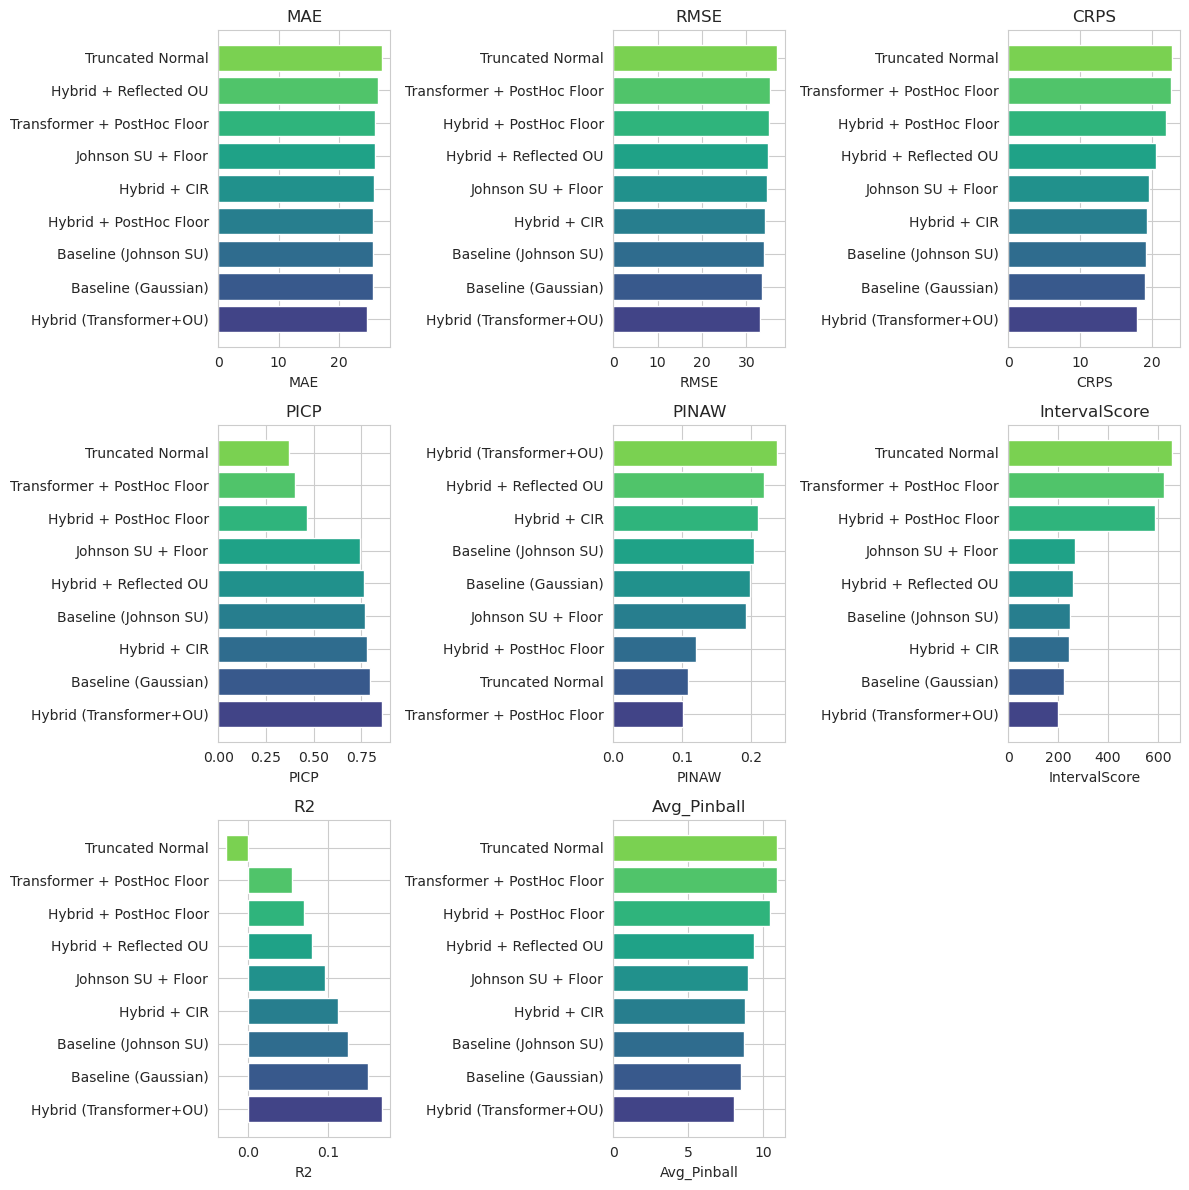

Chart saved to /home/d1ff1cult/masterproef_new/results/price_floor_comparison/comparison_charts.png


In [8]:
# Bar charts for key metrics
if not df_res.empty:
    import matplotlib.pyplot as plt

    metrics_to_plot = ["MAE", "RMSE", "CRPS", "PICP", "PINAW", "IntervalScore", "R2", "Avg_Pinball"]
    metrics_avail = [m for m in metrics_to_plot if m in df_res.columns]
    n_plots = len(metrics_avail)
    n_cols = 3
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    if n_plots == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax, metric in zip(axes[:n_plots], metrics_avail):
        ascending = metric not in ("R2", "PICP")
        df_plot = df_res.sort_values(metric, ascending=ascending)
        colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(df_plot)))
        ax.barh(df_plot["Model"], df_plot[metric], color=colors)
        ax.set_xlabel(metric)
        ax.set_title(metric)

    for ax in axes[n_plots:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "comparison_charts.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to {RESULTS_DIR / 'comparison_charts.png'}")